In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv("churn_2.csv")

In [40]:
df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [42]:
df.isnull().sum()


State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [43]:
encoder = LabelEncoder()

for column in df.columns:

    if df[column].dtype == 'object':

        df[column] = encoder.fit_transform(df[column])

In [44]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [45]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [48]:
y_pred = model.predict(X_test)

In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.897003745318352


In [50]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[455   0]
 [ 55  24]]


In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.89      1.00      0.94       455
        True       1.00      0.30      0.47        79

    accuracy                           0.90       534
   macro avg       0.95      0.65      0.70       534
weighted avg       0.91      0.90      0.87       534



In [52]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print(scores)

print("Average CV Score:", scores.mean())

[0.91198502 0.90056285 0.90056285 0.90243902 0.90056285]
Average CV Score: 0.9032225196927854


In [53]:
importance = model.feature_importances_

In [54]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

In [55]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [56]:
print(feature_importance)

                   Feature  Importance
6        Total day minutes    0.191011
8         Total day charge    0.168467
3       International plan    0.137182
18  Customer service calls    0.117905
11        Total eve charge    0.055479
9        Total eve minutes    0.046343
16        Total intl calls    0.046290
15      Total intl minutes    0.040014
17       Total intl charge    0.036316
5    Number vmail messages    0.030241
4          Voice mail plan    0.027680
14      Total night charge    0.019164
12     Total night minutes    0.018502
7          Total day calls    0.015562
13       Total night calls    0.013275
10         Total eve calls    0.013180
1           Account length    0.011946
0                    State    0.008280
2                Area code    0.003162


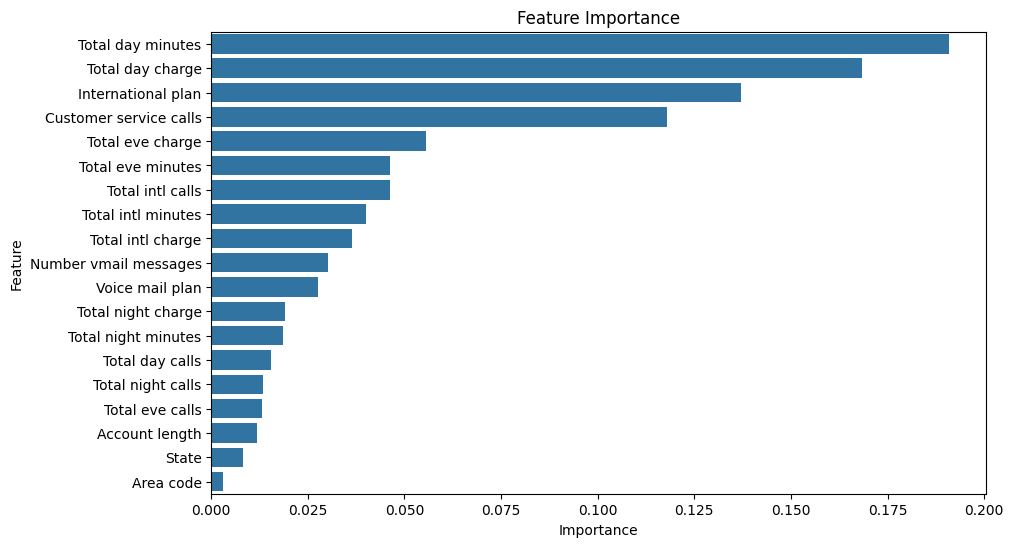

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()